In [1]:
import os
import imdlib as imd
import pandas as pd
import numpy as np

from xgboost import XGBRegressor

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import matplotlib.pyplot as plt
import joblib

In [6]:
import os

print(os.getcwd())

c:\Users\Hitan\Downloads\archive (1)\DigitalTwinClimate\notebooks\notebooks


In [7]:
import os

print(os.listdir("."))

['07_Temperature_XGBoost.ipynb']


In [8]:
print(os.listdir(".."))

['04_humidity_eda.ipynb', '1_data_exploration.ipynb', 'notebooks']


In [9]:
import os

for root, dirs, files in os.walk(".."):
    if "tmax" in dirs:
        print("Found:", os.path.join(root, "tmax"))

In [10]:
import os

for root, dirs, files in os.walk("."):
    if "2020.GRD" in files or "2020.grd" in files:
        print(root)

In [11]:
import os
print(os.getcwd())
print(os.listdir("."))
print(os.listdir(".."))

c:\Users\Hitan\Downloads\archive (1)\DigitalTwinClimate\notebooks\notebooks
['07_Temperature_XGBoost.ipynb']
['04_humidity_eda.ipynb', '1_data_exploration.ipynb', 'notebooks']


In [1]:
import os

print("Current Working Directory:")
print(os.getcwd())

Current Working Directory:
c:\Users\Hitan\Downloads\archive (1)\DigitalTwinClimate\notebooks\notebooks


In [2]:
import os

for root, dirs, files in os.walk("."):
    for file in files:
        if file.lower() == "2020.grd":
            print(os.path.join(root, file))

In [3]:
print

<function print(*args, sep=' ', end='\n', file=None, flush=False)>

In [ ]:
import imdlib as imd

raw_dir = r"C:\Users\Hitan\Downloads\archive (1)\DigitalTwinClimate\data\raw\temperature\tmax"

temp_data = imd.open_data(
    "tmax",
    2020,
    2025,
    "yearwise",
    raw_dir
)

df = temp_data.get_xarray().to_dataframe().reset_index()

print(df.head())

        time  lat   lon       tmax
0 2020-01-01  7.5  67.5  99.900002
1 2020-01-01  7.5  68.5  99.900002
2 2020-01-01  7.5  69.5  99.900002
3 2020-01-01  7.5  70.5  99.900002
4 2020-01-01  7.5  71.5  99.900002


In [1]:
import imdlib as imd

raw_dir = r"C:\Users\Hitan\Downloads\archive (1)\DigitalTwinClimate\data\raw\temperature\tmin"

temp_data = imd.open_data(
    "tmin",
    2020,
    2025,
    "yearwise",
    raw_dir
)

df = temp_data.get_xarray().to_dataframe().reset_index()

print(df.head())

        time  lat   lon       tmin
0 2020-01-01  7.5  67.5  99.900002
1 2020-01-01  7.5  68.5  99.900002
2 2020-01-01  7.5  69.5  99.900002
3 2020-01-01  7.5  70.5  99.900002
4 2020-01-01  7.5  71.5  99.900002


In [7]:
print(df.columns)

Index(['time', 'lat', 'lon', 'tmin'], dtype='object')


In [8]:
df.head()

,time,lat,lon,tmin
0,2020-01-01,7.5,67.5,99.900002
1,2020-01-01,7.5,68.5,99.900002
2,2020-01-01,7.5,69.5,99.900002
3,2020-01-01,7.5,70.5,99.900002
4,2020-01-01,7.5,71.5,99.900002


In [13]:
import numpy as np
import pandas as pd

In [14]:
df["tmin"] = df["tmin"].replace(-999, np.nan)
df = df.dropna(subset=["tmin"])

In [15]:
y = df["tmin"]

In [16]:
y

0          99.900002
1          99.900002
2          99.900002
3          99.900002
4          99.900002
             ...    
2106507    99.900002
2106508    99.900002
2106509    99.900002
2106510    99.900002
2106511    99.900002
Name: tmin, Length: 2106512, dtype: float64

In [17]:

df["year"] = df["time"].dt.year
df["month"] = df["time"].dt.month
df["day"] = df["time"].dt.day
df["dayofyear"] = df["time"].dt.dayofyear


In [18]:
df["lat_lon"] = df["lat"] * df["lon"]



In [19]:

df["month_sin"] = np.sin(2*np.pi*df["month"]/12)
df["month_cos"] = np.cos(2*np.pi*df["month"]/12)

df.head()

,time,lat,lon,tmin,year,month,day,dayofyear,lat_lon,month_sin,month_cos
0,2020-01-01,7.5,67.5,99.900002,2020,1,1,1,506.25,0.5,0.866025
1,2020-01-01,7.5,68.5,99.900002,2020,1,1,1,513.75,0.5,0.866025
2,2020-01-01,7.5,69.5,99.900002,2020,1,1,1,521.25,0.5,0.866025
3,2020-01-01,7.5,70.5,99.900002,2020,1,1,1,528.75,0.5,0.866025
4,2020-01-01,7.5,71.5,99.900002,2020,1,1,1,536.25,0.5,0.866025


In [21]:
features = [
    "lat",
    "lon",
    "year",
    "month",
    "day",
    "dayofyear",
    "lat_lon",
    "month_sin",
    "month_cos"
]

X = df[features]
y = df["tmin"]

In [22]:
X

,lat,lon,year,month,day,dayofyear,lat_lon,month_sin,month_cos
0,7.5,67.5,2020,1,1,1,506.25,5.000000e-01,0.866025
1,7.5,68.5,2020,1,1,1,513.75,5.000000e-01,0.866025
2,7.5,69.5,2020,1,1,1,521.25,5.000000e-01,0.866025
3,7.5,70.5,2020,1,1,1,528.75,5.000000e-01,0.866025
4,7.5,71.5,2020,1,1,1,536.25,5.000000e-01,0.866025
...,...,...,...,...,...,...,...,...,...
2106507,37.5,93.5,2025,12,31,365,3506.25,-2.449294e-16,1.000000
2106508,37.5,94.5,2025,12,31,365,3543.75,-2.449294e-16,1.000000
2106509,37.5,95.5,2025,12,31,365,3581.25,-2.449294e-16,1.000000
2106510,37.5,96.5,2025,12,31,365,3618.75,-2.449294e-16,1.000000


In [23]:
y

0          99.900002
1          99.900002
2          99.900002
3          99.900002
4          99.900002
             ...    
2106507    99.900002
2106508    99.900002
2106509    99.900002
2106510    99.900002
2106511    99.900002
Name: tmin, Length: 2106512, dtype: float64

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [25]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

print("Training model...")


Training model...


In [26]:
model.fit(X_train, y_train)

print("Training Completed!")

Training Completed!


In [27]:
prediction = model.predict(X_test)

In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, prediction)
rmse = np.sqrt(mean_squared_error(y_test, prediction))
r2 = r2_score(y_test, prediction)

print("Model Performance")
print("---------------------")
print(f"MAE : {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²  : {r2:.2f}")


Model Performance
---------------------
MAE : 0.522
RMSE: 1.424
R²  : 1.00


In [33]:
print("Missing Values")
print(df.isnull().sum())

print("\nMissing Percentage")
print((df.isnull().sum() / len(df)) * 100)

Missing Values
time         0
lat          0
lon          0
tmin         0
year         0
month        0
day          0
dayofyear    0
lat_lon      0
month_sin    0
month_cos    0
dtype: int64

Missing Percentage
time         0.0
lat          0.0
lon          0.0
tmin         0.0
year         0.0
month        0.0
day          0.0
dayofyear    0.0
lat_lon      0.0
month_sin    0.0
month_cos    0.0
dtype: float64


In [34]:
df["tmin"] = df["tmin"].replace(99.9, np.nan)

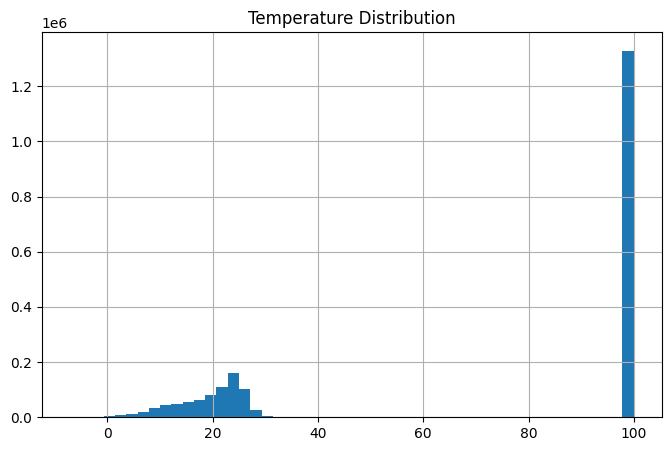

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
df["tmin"].hist(bins=50)
plt.title("Temperature Distribution")
plt.show()

In [39]:
df = df.dropna()

In [40]:
print(df.isnull().sum())

time         0
lat          0
lon          0
tmin         0
year         0
month        0
day          0
dayofyear    0
lat_lon      0
month_sin    0
month_cos    0
dtype: int64


In [41]:
df["year"] = df["time"].dt.year
df["month"] = df["time"].dt.month
df["day"] = df["time"].dt.day
df["dayofyear"] = df["time"].dt.dayofyear

df["week"] = df["time"].dt.isocalendar().week.astype(int)

df["lat_lon"] = df["lat"] * df["lon"]

df["month_sin"] = np.sin(2*np.pi*df["month"]/12)
df["month_cos"] = np.cos(2*np.pi*df["month"]/12)

In [43]:
train = df[df["year"] <= 2024]
test = df[df["year"] == 2025]

features = [
    "lat",
    "lon",
    "month",
    "day",
    "dayofyear",
    "lat_lon",
    "month_sin",
    "month_cos"
]

X_train = train[features]
y_train = train["tmin"]

X_test = test[features]
y_test = test["tmin"]

In [46]:
print(X_train.columns.tolist())
print(X_test.columns.tolist())

['lat', 'lon', 'month', 'day', 'dayofyear', 'lat_lon', 'month_sin', 'month_cos']
['lat', 'lon', 'month', 'day', 'dayofyear', 'lat_lon', 'month_sin', 'month_cos']


In [47]:
df["year"] = df["time"].dt.year
df["month"] = df["time"].dt.month
df["day"] = df["time"].dt.day
df["dayofyear"] = df["time"].dt.dayofyear

df["lat_lon"] = df["lat"] * df["lon"]

df["month_sin"] = np.sin(2*np.pi*df["month"]/12)
df["month_cos"] = np.cos(2*np.pi*df["month"]/12)

In [ ]:
features = [
    "lat",
    "lon",
    "year",
    "month",
    "day",
    "dayofyear",
    "lat_lon",
    "month_sin",
    "month_cos"
]

X = df[features]

y = df["tmin"]     

In [49]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [50]:
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [51]:
prediction = model.predict(X_test)

In [55]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, prediction)
rmse = np.sqrt(mean_squared_error(y_test, prediction))
r2 = r2_score(y_test, prediction)

print("Model Performance")

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.2f}")

Model Performance
MAE : 0.52
RMSE: 1.42
R²  : 1.00


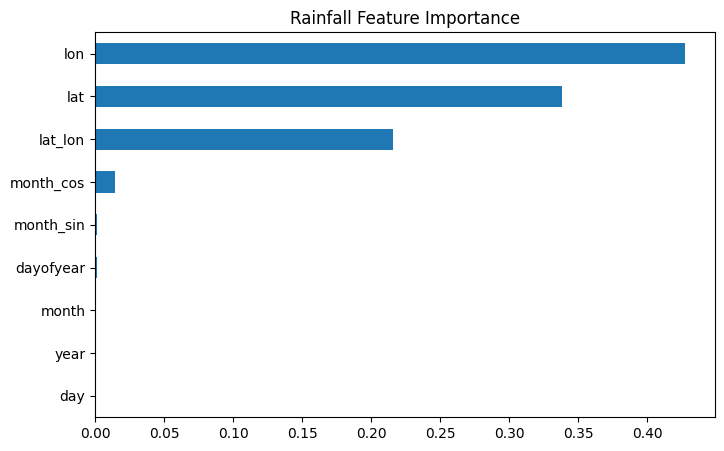

In [56]:
importance = pd.Series(
    model.feature_importances_,
    index=features
)

importance.sort_values().plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Rainfall Feature Importance")
plt.show()

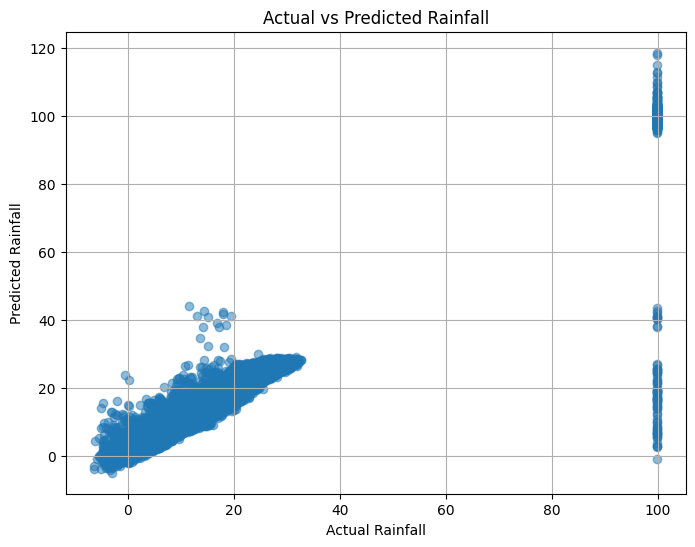

In [57]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    prediction,
    alpha=0.5
)

plt.xlabel("Actual Rainfall")
plt.ylabel("Predicted Rainfall")
plt.title("Actual vs Predicted Rainfall")

plt.grid(True)

plt.show()

In [59]:
loaded_model = joblib.load("../models/rainfall_xgboost.pkl")

print(loaded_model)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)


In [62]:
print(df.head())

        time  lat   lon       tmin  year  month  day  dayofyear  lat_lon  \
0 2020-01-01  7.5  67.5  99.900002  2020      1    1          1   506.25   
1 2020-01-01  7.5  68.5  99.900002  2020      1    1          1   513.75   
2 2020-01-01  7.5  69.5  99.900002  2020      1    1          1   521.25   
3 2020-01-01  7.5  70.5  99.900002  2020      1    1          1   528.75   
4 2020-01-01  7.5  71.5  99.900002  2020      1    1          1   536.25   

   month_sin  month_cos  week  
0        0.5   0.866025     1  
1        0.5   0.866025     1  
2        0.5   0.866025     1  
3        0.5   0.866025     1  
4        0.5   0.866025     1  


In [63]:
df["year"] = df["time"].dt.year
df["month"] = df["time"].dt.month
df["day"] = df["time"].dt.day
df["dayofyear"] = df["time"].dt.dayofyear

In [3]:
import imdlib as imd
import pandas as pd
import numpy as np

raw_dir = r"C:\Users\Hitan\Downloads\archive (1)\DigitalTwinClimate\data\raw\temperature\tmax"

temp_data = imd.open_data(
    "tmax",
    2020,
    2025,
    "yearwise",
    raw_dir
)

df = temp_data.get_xarray().to_dataframe().reset_index()

print(df.head())

        time  lat   lon       tmax
0 2020-01-01  7.5  67.5  99.900002
1 2020-01-01  7.5  68.5  99.900002
2 2020-01-01  7.5  69.5  99.900002
3 2020-01-01  7.5  70.5  99.900002
4 2020-01-01  7.5  71.5  99.900002


In [4]:
df = df.rename(columns={
    "lat": "latitude",
    "lon": "longitude",
    "tmax": "temperature_c"
})

df["temperature_c"] = df["temperature_c"].replace(-999, np.nan)

df = df.dropna()

print(df.head())

        time  latitude  longitude  temperature_c
0 2020-01-01       7.5       67.5      99.900002
1 2020-01-01       7.5       68.5      99.900002
2 2020-01-01       7.5       69.5      99.900002
3 2020-01-01       7.5       70.5      99.900002
4 2020-01-01       7.5       71.5      99.900002


In [5]:
df["year"] = df["time"].dt.year
df["month"] = df["time"].dt.month
df["day"] = df["time"].dt.day
df["hour"] = 0
df["dayofyear"] = df["time"].dt.dayofyear

In [6]:
features = [
    "latitude",
    "longitude",
    "year",
    "month",
    "day",
    "hour",
    "dayofyear"
]

X = df[features]

y = df["temperature_c"]

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [8]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    objective="reg:squarederror",
    random_state=42
)

print("Training...")

model.fit(X_train, y_train)

print("Training Complete")

Training...
Training Complete


In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

prediction = model.predict(X_test)

print("MAE :", mean_absolute_error(y_test, prediction))
print("RMSE:", np.sqrt(mean_squared_error(y_test, prediction)))
print("R²  :", r2_score(y_test, prediction))

MAE : 0.7208040100502013
RMSE: 1.8078939593210201
R²  : 0.9970946299643828


In [10]:
import os
import joblib

os.makedirs("../models", exist_ok=True)

joblib.dump(model, "../models/temperature_xgboost.pkl")

print("Temperature model saved successfully!")

Temperature model saved successfully!


In [11]:
sample = pd.DataFrame({
    "latitude": [19.0760],
    "longitude": [72.8777],
    "year": [2025],
    "month": [7],
    "day": [10],
    "hour": [0],
    "dayofyear": [191]
})

prediction = model.predict(sample)

print(f"Predicted Temperature: {prediction[0]:.2f} °C")

Predicted Temperature: 27.58 °C
